# **Проект ML 1** 

## 0. Введение

— Приведите 5 примеров применения методов машинного обучения в жизни

1. Прогнозирование на основе медицинских показателей и анализов, необходимость введения какого-то вещества.

Преимущество: модель сможет быстрее проанализировать анализы человека и врачи не потеряют время на принятия решения.

2. Прогнозирование наличия психологического или ментального заболевания у человека на основе его ответов в анкете.

Преимущество: быстрая скорость выявления психологического или ментального заболевания у пациента, нет необходимости вручную обрабатывать анкеты.

3. Прогнозирование самых покупаемых позиций в кофейне/кафе/ресторане.

Преимущество: маркетологи смогут быстрее вычислить любимые позиции посетителей и выработать дополнительные стратегии, выгодные для кофейни/кафе/ресторана.

4. Прогнозирование покупательского поведения клиентов

Преимущество: помогает определить факторы, влияющие на доходы, оптимизации маркетинговых стратегий, совершенствовании управления запасами и принятии решений на основе данных для повышения общей прибыльности.

5. Прогнозирование работоспособности устройства

Преимущество: сервисные центры смогут определить необходимость запасных деталей для починки, производство сможет доработать опреденные устройства и знать риск брака.

— Используйте классификацию задач во введении, чтобы определить, к какому классу можно отнести задачи из таблицы выше и 5 приведённых вами примеров.

1. Спрогнозируйте цену дома – регрессия
2. Предскажите, вернёт ли клиент кредит – классификация
3. Прогнозируйте, когда пациенту нужно принять лекарство – регрессия
4. Выберите из имеющихся лекарств то, которое должен принимать пациент – классификация
5. Выберите сегмент клиентов для рекламной кампании – кластеризация
6. Выявление бракованной продукции на производственной линии (на основе фотосканирования) – классификация
7. Решите, как разместить товары на полке в магазине – ассоциация
8. Поисковые сайты для ввода текстового запроса – классификация
9. Разделите клиентов магазина на сегменты, чтобы понять различия в их поведении – кластеризация / регрессия
10. Обнаружение аномалий в трафике сайта – классификация
11. Прогнозирование на основе медицинских показателей и анализов, необходимость введения какого-то вещества. – регрессия
12. Прогнозирование наличия психологического или ментального заболевания у человека на основе его ответов в анкете. – классификация
13. Прогнозирование самых покупаемых позиций в кофейне/кафе/ресторане. – регрессия
14. Прогнозирование покупательского поведения клиентов – кластеризация / регрессия
15. Прогнозирование работоспособности устройства – классификация

— Подумайте, в чём разница между многоклассовым и многометочным.

В машинном обучении многоклассовая классификация предполагает, что каждый объект относится только к одному из нескольких возможных классов. В то же время многометочная классификация позволяет присваивать объекту сразу несколько меток, то есть он может принадлежать к нескольким классам одновременно.

— Является ли пример с ценами на дома из теории классификацией регрессионной задачи? Можно ли свести регрессионную задачу к классификации?

Данную задачу можно отнести к регрессионной задаче, так как мы хотим предсказать значение действительной величины. Да, регрессионную задачу можно свести к классификации, если применим метод для уменьшения количества непрерывных переменных в наборе данных для целевого признака.

## 1. Введение в анализ данных

Подключение библиотек

Импортируйте библиотеки pandas, numpy, sklearn, lightgbm, scipy, statsmodels, matplotlib, seaborn. При необходимости используйте pip install.

In [449]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [450]:
import pandas as pd
import numpy as np
from sklearn import datasets, model_selection, metrics
import lightgbm as lgb
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline

In [451]:
df = pd.read_json('data/train.json')

Выводит количество столбцов и элементов в строке

In [452]:
df.shape

(49352, 15)

Вывод всех столбцов

In [453]:
df.columns.tolist()

['bathrooms',
 'bedrooms',
 'building_id',
 'created',
 'description',
 'display_address',
 'features',
 'latitude',
 'listing_id',
 'longitude',
 'manager_id',
 'photos',
 'price',
 'street_address',
 'interest_level']

Столбец "interest_level" считается целевым

In [454]:
df["interest_level"].value_counts()

interest_level
low       34284
medium    11229
high       3839
Name: count, dtype: int64

In [455]:
X = df.drop("interest_level", axis=1) 
y = df["interest_level"]         

**Выводит информацию о всех столбцах.**

В выводе название столбцов и тип данных, удобно для быстрого анализа датасета.

In [456]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  object 
 3   created          49352 non-null  object 
 4   description      49352 non-null  object 
 5   display_address  49352 non-null  object 
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  object 
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  object 
 14  interest_level   49352 non-null  object 
dtypes: float64(3), int64(3), object(9)
memory usage: 6.0+ MB


**Показывает основные статистические данные по столбцам.**

В выводе используются основные значения по столбцам, такие как среднее значение, минимальное, максимальное и так далее.

In [457]:
df.describe()

,bathrooms,bedrooms,latitude,listing_id,longitude,price
count,49352.00000,49352.000000,49352.000000,4.935200e+04,49352.000000,4.935200e+04
mean,1.21218,1.541640,40.741545,7.024055e+06,-73.955716,3.830174e+03
std,0.50142,1.115018,0.638535,1.262746e+05,1.177912,2.206687e+04
min,0.00000,0.000000,0.000000,6.811957e+06,-118.271000,4.300000e+01
25%,1.00000,1.000000,40.728300,6.915888e+06,-73.991700,2.500000e+03
50%,1.00000,1.000000,40.751800,7.021070e+06,-73.977900,3.150000e+03
75%,1.00000,2.000000,40.774300,7.128733e+06,-73.954800,4.100000e+03
max,10.00000,8.000000,44.883500,7.753784e+06,0.000000,4.490000e+06


**Рассчитывает корреляцию между числовыми столбцами.**

In [458]:
df.corr(numeric_only=True)

,bathrooms,bedrooms,latitude,listing_id,longitude,price
bathrooms,1.000000,0.533446,-0.009657,0.000776,0.010393,0.069661
bedrooms,0.533446,1.000000,-0.004745,0.011968,0.006892,0.051788
latitude,-0.009657,-0.004745,1.000000,0.001712,-0.966807,-0.000707
listing_id,0.000776,0.011968,0.001712,1.000000,-0.000907,0.008090
longitude,0.010393,0.006892,-0.966807,-0.000907,1.000000,-0.000087
price,0.069661,0.051788,-0.000707,0.008090,-0.000087,1.000000


В скобках у функции corr() добавлено "numeric_only=True", так как не все строки преобразовываются в формат float. Из-за этого код не срабатывал и не получалось рассчитать статистическую взаимосвязь величин (корреляцию). Благодаря такому добавлению к нашей функции, я смогла получить в выводе те столбцы, которые адаптируются в нужный формат для корреляции.

In [459]:
new = ['bathrooms', 'bedrooms', 'interest_level', 'price']
df_new = df[new].copy()
df_new.head()

,bathrooms,bedrooms,interest_level,price
4,1.0,1,medium,2400
6,1.0,2,low,3800
9,1.0,2,medium,3495
10,1.5,3,medium,3000
15,1.0,0,low,2795


Определение признака и целевой переменной в новом dataframe для работы

In [460]:
X = df_new.drop('price', axis=1)
y = df_new['price']

## 2. Анализ статистических данных

### Целевой анализ

Гистограмма до удаления строк

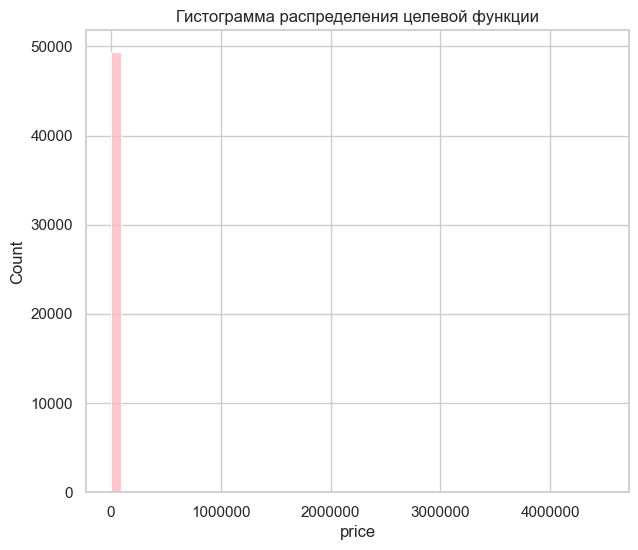

In [461]:
plt.figure(figsize=(7, 6))
sns.histplot(df_new['price'], color='lightpink', bins=50)
plt.title("Гистограмма распределения целевой функции")

plt.ticklabel_format(axis='x', style='plain', useLocale=True)

plt.show()

Ящик с усами.

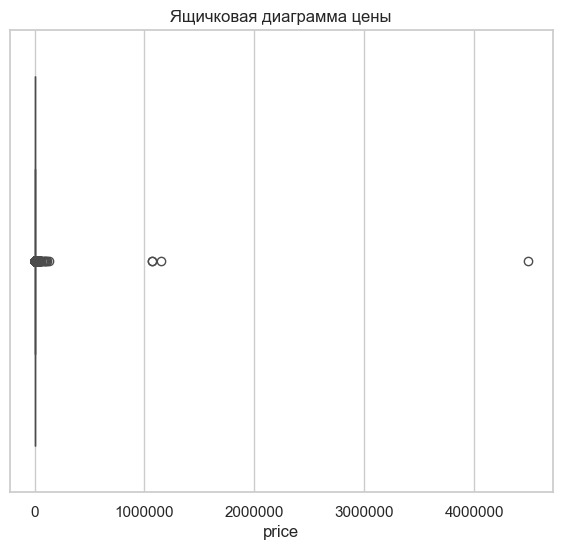

In [462]:
plt.figure(figsize=(7, 6))
sns.boxplot(x=df_new['price'])
plt.title("Ящичковая диаграмма цены")

plt.ticklabel_format(axis='x', style='plain', useLocale=True)

plt.show()

На данном графике есть сильная ассиметрия, так как ящик смещён влево ближе к 0, выбросы тянутся вправо => большиство цен низкие, но есть редкие дорогие объекты. Такое поведение довольно типично для недвижимости. Основная масса цен сосредоточена в относительно низком диапазоне. Большой разброс между Q1 и Q3 свидетельствует о высокой вариативности цен.

IQR метод – нахожу выбросы, которые происходят между Q1 и Q3, иначе межквартильный размах

In [463]:
Q1 = df_new['price'].quantile(0.25)
Q3 = df_new['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Выбросы ниже {lower_bound:,.0f} или выше {upper_bound:,.0f}")

Выбросы ниже 100 или выше 6,500


Удаляю строки, которые находятся за пределами 1-го и 99-го процентилей в целевом столбце, в соотвествии заданию

In [464]:
lower_bound = df_new['price'].quantile(0.01)
upper_bound = df_new['price'].quantile(0.99)
df_clean = df_new[(df_new['price'] >= lower_bound) & (df_new['price'] <= upper_bound)]

Гистограмма после удаления строк

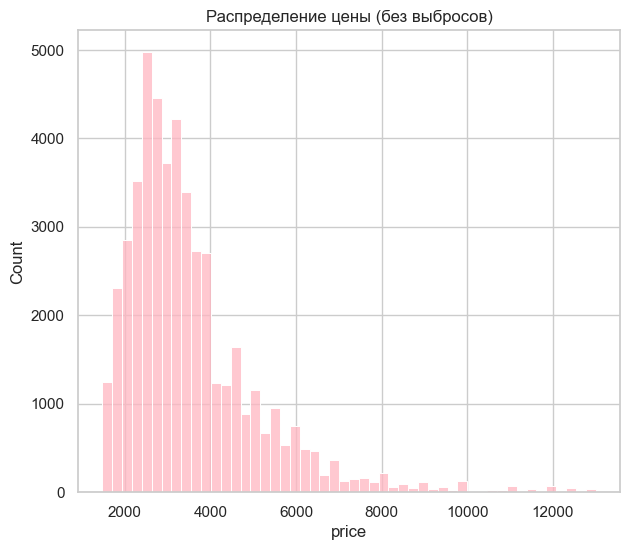

In [465]:
plt.figure(figsize=(7, 6))
sns.histplot(df_clean['price'], color='lightpink', bins=50, kde=False)
plt.title("Распределение цены (без выбросов)")
plt.show()

Основная масса предложений (60-70%) сосредоточена в нижнем ценовом диапазоне. По мере движения вправо по ценовой шкале наблюдается плавный, но устойчивый спад количества предложений. Выделяет три ключевых сегмента: бюджетный (до моды), средний (мода-медиана), премиальный (после медианы).

UPD: мода – значение, которое встречается чаще всего.

### Анализ характеристик

In [466]:
df_clean['interest_level'].dtype

dtype('O')

In [467]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48379 entries, 4 to 124009
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   bathrooms       48379 non-null  float64
 1   bedrooms        48379 non-null  int64  
 2   interest_level  48379 non-null  object 
 3   price           48379 non-null  int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 1.8+ MB


Столбец 'interest_level' относится к типу данных 'object'.

In [468]:
df_clean['interest_level'].value_counts()

interest_level
low       33697
medium    11116
high       3566
Name: count, dtype: int64

Закодировала значения в соответсвии 'low': 0, 'medium': 1, 'high': 2 (сделала словарь, скажем так)

In [469]:
interest_mapping = {'low': 0, 'medium': 1, 'high': 2}
df_clean['interest_level_encoded'] = df_clean['interest_level'].map(interest_mapping)

C:\Users\alena\AppData\Local\Temp\ipykernel_25024\185671695.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['interest_level_encoded'] = df_clean['interest_level'].map(interest_mapping)


Гистограмма для 'bathrooms'

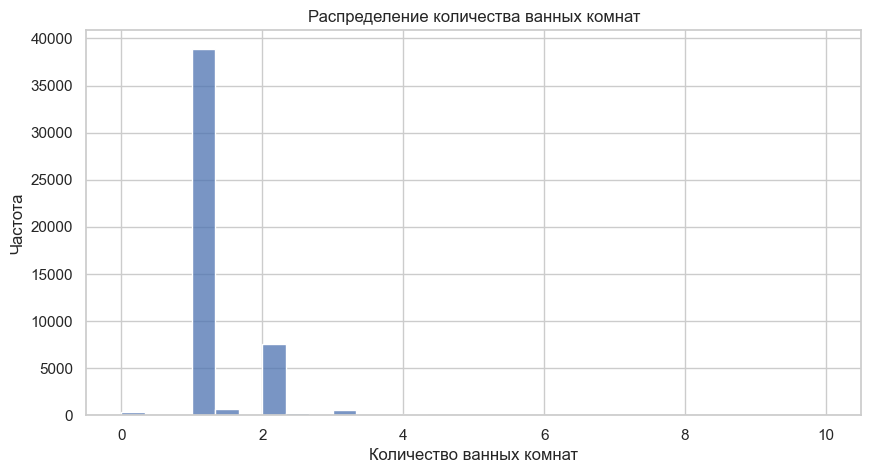

In [470]:
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['bathrooms'], bins=30)
plt.title('Распределение количества ванных комнат')
plt.xlabel('Количество ванных комнат')
plt.ylabel('Частота')
plt.show()

Гистограмма для 'bedrooms'

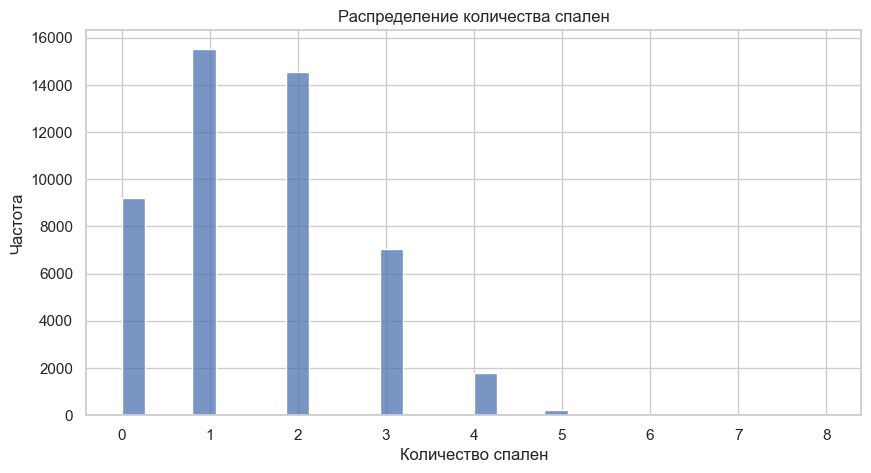

In [471]:
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['bedrooms'], bins=30)
plt.title('Распределение количества спален')
plt.xlabel('Количество спален')
plt.ylabel('Частота')
plt.show()

Определение выбросов

In [472]:
print("Выбросы для 'bathrooms':")
print(df_clean['bathrooms'].describe())

print("\nВыбросы для 'bedrooms':")
print(df_clean['bedrooms'].describe())

Выбросы для 'bathrooms':
count    48379.000000
mean         1.195198
std          0.456495
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         10.000000
Name: bathrooms, dtype: float64

Выбросы для 'bedrooms':
count    48379.000000
mean         1.534633
std          1.101477
min          0.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          8.000000
Name: bedrooms, dtype: float64


Выбросы присутствуют у 'bathrooms', так как 75% данных имеют 1 ванную комнату, но максимальное значение 10, это явно выброс. У 'bedrooms' аналогичная история. Чтобы это проверить, можно применить метод IQR и найти верхнюю границу:

**IQR = Q3 - Q1**

**Верхняя граница = Q3 + 1.5*IQR**

'bathrooms' = 2,5 (округляем до 3), 'bedrooms' =  3,5 (округляем до 4)



### Комплексный анализ

Тепловая карта для матрицы корреляций

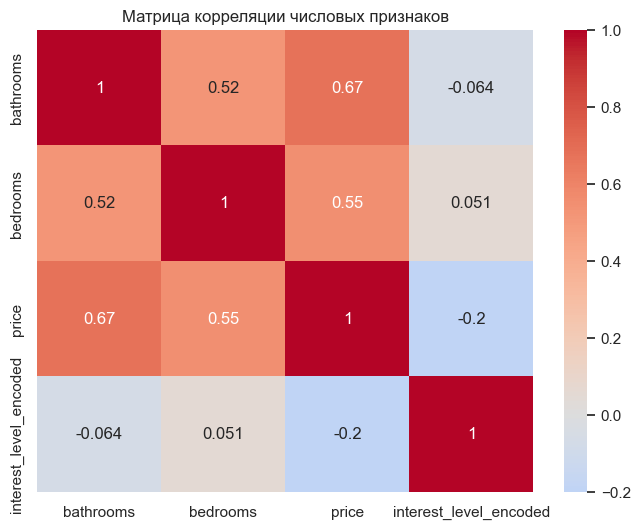

In [473]:
numeric_features = ['bathrooms', 'bedrooms', 'price', 'interest_level_encoded']
correlation_matrix = df_clean[numeric_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Матрица корреляции числовых признаков')
plt.show()

_Корреляция есть в большей части карты, т.к. 1 – это полная прямая зависимость, -1 – это обратная зависимость, 0 – отсутствие линейной связи_

Точечная диаграмма  (3 графика)

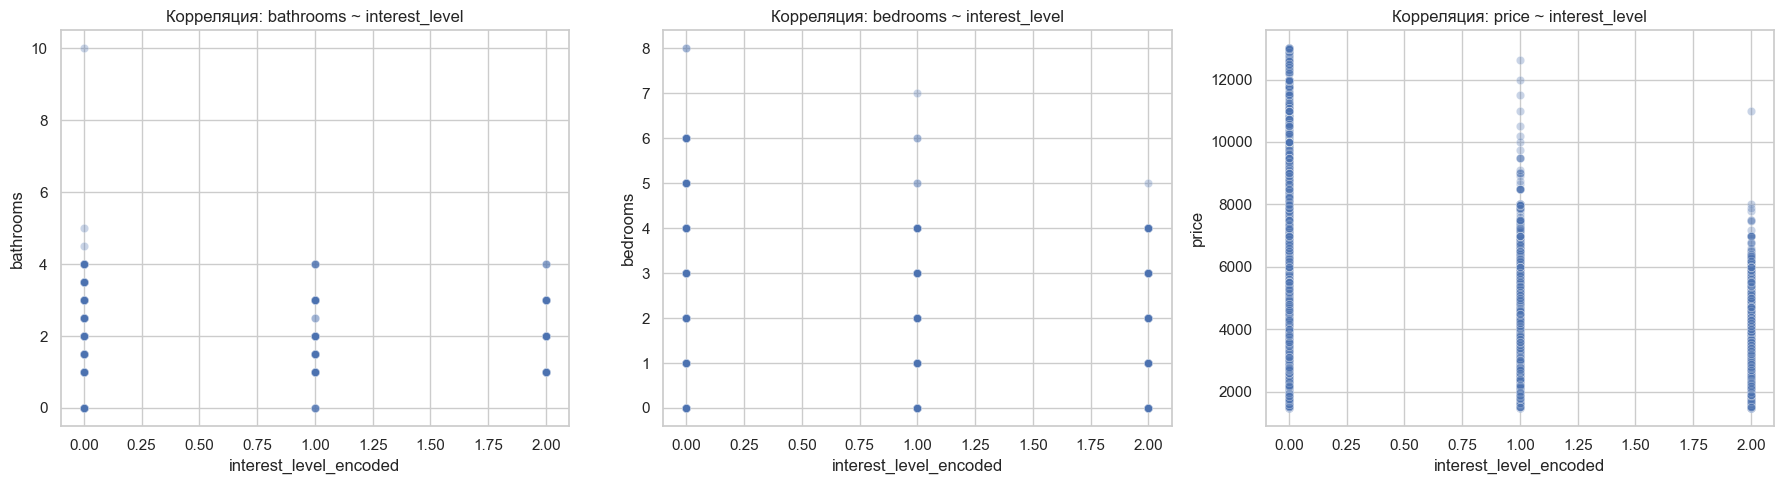

In [474]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# График 1: bathrooms, interest_level
sns.scatterplot(ax=axes[0], x='interest_level_encoded', y='bathrooms', data=df_clean, alpha=0.3)
axes[0].set_title('Корреляция: bathrooms ~ interest_level')

# График 2: bedrooms, interest_level
sns.scatterplot(ax=axes[1], x='interest_level_encoded', y='bedrooms', data=df_clean, alpha=0.3)
axes[1].set_title('Корреляция: bedrooms ~ interest_level')

# График 3: price, interest_level
sns.scatterplot(ax=axes[2], x='interest_level_encoded', y='price', data=df_clean, alpha=0.3)
axes[2].set_title('Корреляция: price ~ interest_level')

plt.tight_layout()
plt.show()

## 3. Создание функций

_UPD: по инструкции просят "перемещайте импорты и функции в начало блокнота", но у меня находится здесь, так как последовательно шла по заданию и мне проще так ориентироваться. Прошу понять, принять и простить._

In [475]:
train_data = pd.read_json('data/train.json')
test_data = pd.read_json('data/test.json')

In [477]:
def f1(df):
    df = df.copy()
    df['bathrooms_squared'] = df['bathrooms'] ** 2
    return df  

def f2(df):
    df = df.copy()
    df['bedrooms_squared'] = df['bedrooms'] ** 2
    return df  

def f3(df):
    df['interest_level_squared'] = df['interest_level'].map({'low': 0, 'medium': 1, 'high': 2}) ** 2
    return df

In [478]:
def f123(df):
    df = f1(df)
    df = f2(df)
    df = f3(df)
    return df 

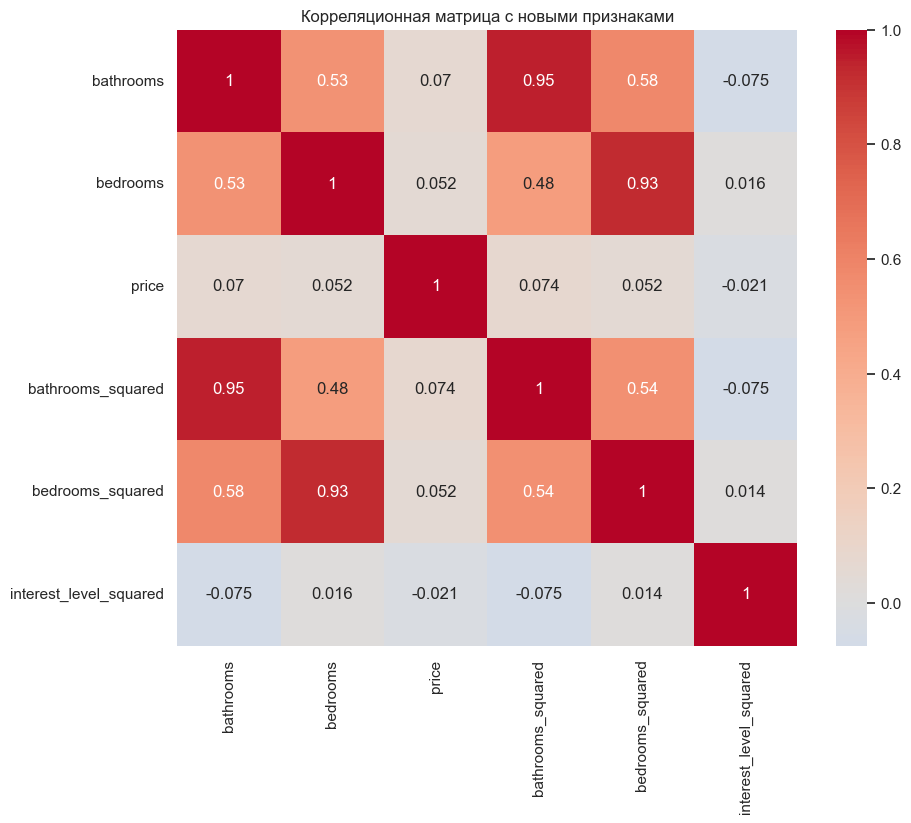

In [479]:
def plot_correlation_matrix(df):
    target_cols = [
        'bathrooms', 'bedrooms', 'price', 
        'bathrooms_squared', 'bedrooms_squared', 
        'interest_level_squared'
    ]
    
    numerical_cols = [col for col in target_cols 
                     if col in df.columns and pd.api.types.is_numeric_dtype(df[col])]
    
    corr_matrix = df[numerical_cols].corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
    plt.title("Корреляционная матрица с новыми признаками")
    plt.show()
    
train_data = pd.read_json('data/train.json')
train_data_with_squares = f123(train_data)
plot_correlation_matrix(train_data_with_squares)

Понимаю, что тут уместнее использовать было f1(), f2(), f3() – объединенные в f123(). Но тогда столбец 'interest_level' перебивается в значения NaN и исправить данную ситуацию у меня не получилось.	

In [480]:
df['interest_level'] = df['interest_level'].map({'low': 0, 'medium': 1, 'high': 2}).astype('float64')

df['bathrooms_squared'] = df['bathrooms'] ** 2
df['bedrooms_squared'] = df['bedrooms'] ** 2
df['interest_level_squared'] = df['interest_level'] ** 2

target_cols = [
    'bathrooms', 'bedrooms', 'interest_level', 'price',
    'bathrooms_squared', 'bedrooms_squared',
    'interest_level_squared'
]
  
corr_matrix = df[target_cols].corr()
corr_matrix

,bathrooms,bedrooms,interest_level,price,bathrooms_squared,bedrooms_squared,interest_level_squared
bathrooms,1.000000,0.533446,-0.082573,0.069661,0.948078,0.576067,-0.074947
bedrooms,0.533446,1.000000,0.027293,0.051788,0.479853,0.928373,0.016339
interest_level,-0.082573,0.027293,1.000000,-0.023783,-0.085297,0.023406,0.945425
price,0.069661,0.051788,-0.023783,1.000000,0.073514,0.052395,-0.021022
bathrooms_squared,0.948078,0.479853,-0.085297,0.073514,1.000000,0.540462,-0.075253
bedrooms_squared,0.576067,0.928373,0.023406,0.052395,0.540462,1.000000,0.013757
interest_level_squared,-0.074947,0.016339,0.945425,-0.021022,-0.075253,0.013757,1.000000


**Вывод:** новые признаки НЕ коррелируют с целевым показателем сильнее, чем исходные признаки

Признаки (X), а целевая переменная (y)

In [481]:
X_train = train_data[['bathrooms', 'bedrooms']].values
X_test = test_data[['bathrooms', 'bedrooms']].values

y_train = train_data['price'].values  
y_test = test_data['price'].values

In [482]:
poly = PolynomialFeatures(degree=10, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

## 4. Обучение трех моделей

In [483]:
result_MAE = pd.DataFrame()
result_RMSE = pd.DataFrame()

In [484]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

**1. Линейная регрессия**

Масштабирование для линейной регрессии

In [485]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)

In [486]:
result_MAE = pd.DataFrame(columns=['model', 'train', 'test'])
result_RMSE = pd.DataFrame(columns=['model', 'train', 'test'])

In [487]:
linreg = make_pipeline(StandardScaler(), LinearRegression())
linreg.fit(X_train_poly, y_train)

train_pred_lin = linreg.predict(X_train_poly)
test_pred_lin = linreg.predict(X_test_poly)

In [488]:
result_MAE = pd.concat([
    result_MAE,
    pd.DataFrame({
        'model': ['linreg'],
        'train': [mean_absolute_error(y_train, train_pred_lin)],
        'test': [mean_absolute_error(y_test, test_pred_lin)]
    })
], ignore_index=True)

result_RMSE = pd.concat([
    result_RMSE,
    pd.DataFrame({
        'model': ['linreg'],
        'train': [np.sqrt(mean_squared_error(y_train, train_pred_lin))],
        'test': [np.sqrt(mean_squared_error(y_test, test_pred_lin))]
    })
], ignore_index=True)

C:\Users\alena\AppData\Local\Temp\ipykernel_25024\2713928880.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result_MAE = pd.concat([
C:\Users\alena\AppData\Local\Temp\ipykernel_25024\2713928880.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result_RMSE = pd.concat([


**2. Дерево принятия решений**

In [489]:
tree = DecisionTreeRegressor(random_state=21)
tree.fit(X_train_poly, y_train)

train_pred_tree = tree.predict(X_train_poly)
test_pred_tree = tree.predict(X_test_poly)

In [490]:
result_MAE = pd.concat([
    result_MAE,
    pd.DataFrame({
        'model': ['tree'],
        'train': [mean_absolute_error(y_train, train_pred_tree)],
        'test': [mean_absolute_error(y_test, test_pred_tree)]
    })
], ignore_index=True)

result_RMSE = pd.concat([
    result_RMSE,
    pd.DataFrame({
        'model': ['tree'],
        'train': [np.sqrt(mean_squared_error(y_train, train_pred_tree))],
        'test': [np.sqrt(mean_squared_error(y_test, test_pred_tree))]
    })
], ignore_index=True)

**3. Наивные модели**

Медиана и среднее цены

In [491]:
mean_price = np.mean(y_train)  
median_price = np.median(y_train) 

Новые столбцы с предсказаниями (среднее и медиана)

In [492]:
train_pred_mean = np.full_like(y_train, mean_price)
test_pred_mean = np.full_like(y_test, mean_price)

train_pred_median = np.full_like(y_train, median_price)
test_pred_median = np.full_like(y_test, median_price)

In [493]:
result_MAE = pd.concat([
    result_MAE,
    pd.DataFrame({
        'model': ['mean', 'median'],
        'train': [
            mean_absolute_error(y_train, train_pred_mean),
            mean_absolute_error(y_train, train_pred_median)
        ],
        'test': [
            mean_absolute_error(y_test, test_pred_mean),
            mean_absolute_error(y_test, test_pred_median)
        ]
    })
], ignore_index=True)

result_RMSE = pd.concat([
    result_RMSE,
    pd.DataFrame({
        'model': ['mean', 'median'],
        'train': [
            np.sqrt(mean_squared_error(y_train, train_pred_mean)),
            np.sqrt(mean_squared_error(y_train, train_pred_median))
        ],
        'test': [
            np.sqrt(mean_squared_error(y_test, test_pred_mean)),
            np.sqrt(mean_squared_error(y_test, test_pred_median))
        ]
    })
], ignore_index=True)

**Итоговые таблицы result_MAE и result_RMSE.**

In [494]:
result_MAE

,model,train,test
0,linreg,1084.358648,1134.491505
1,tree,1058.108940,996.214780
2,mean,1549.572358,1472.087973
3,median,1400.344403,1322.640673


In [495]:
result_RMSE

,model,train,test
0,linreg,22001.701520,34070.291635
1,tree,21992.863614,9580.405424
2,mean,22066.642318,9713.364025
3,median,22077.122545,9731.481148


Дерево решений показала лучше результаты, чем остальные модели. Так как она выдает точные и стабильные результаты. Разница между train и test небольшая, следовательно не происходит переобучение.